# Colab 1. Методы XDM: безмодельный отбор и объяснение признаков

Этот блокнот даёт развернутый обзор методов, которые используются для объяснимого анализа табличных данных до построения модели. Сначала рассматриваются существующие направления, затем формально описываются методы, входящие в ядро MFEX.

<p align="center">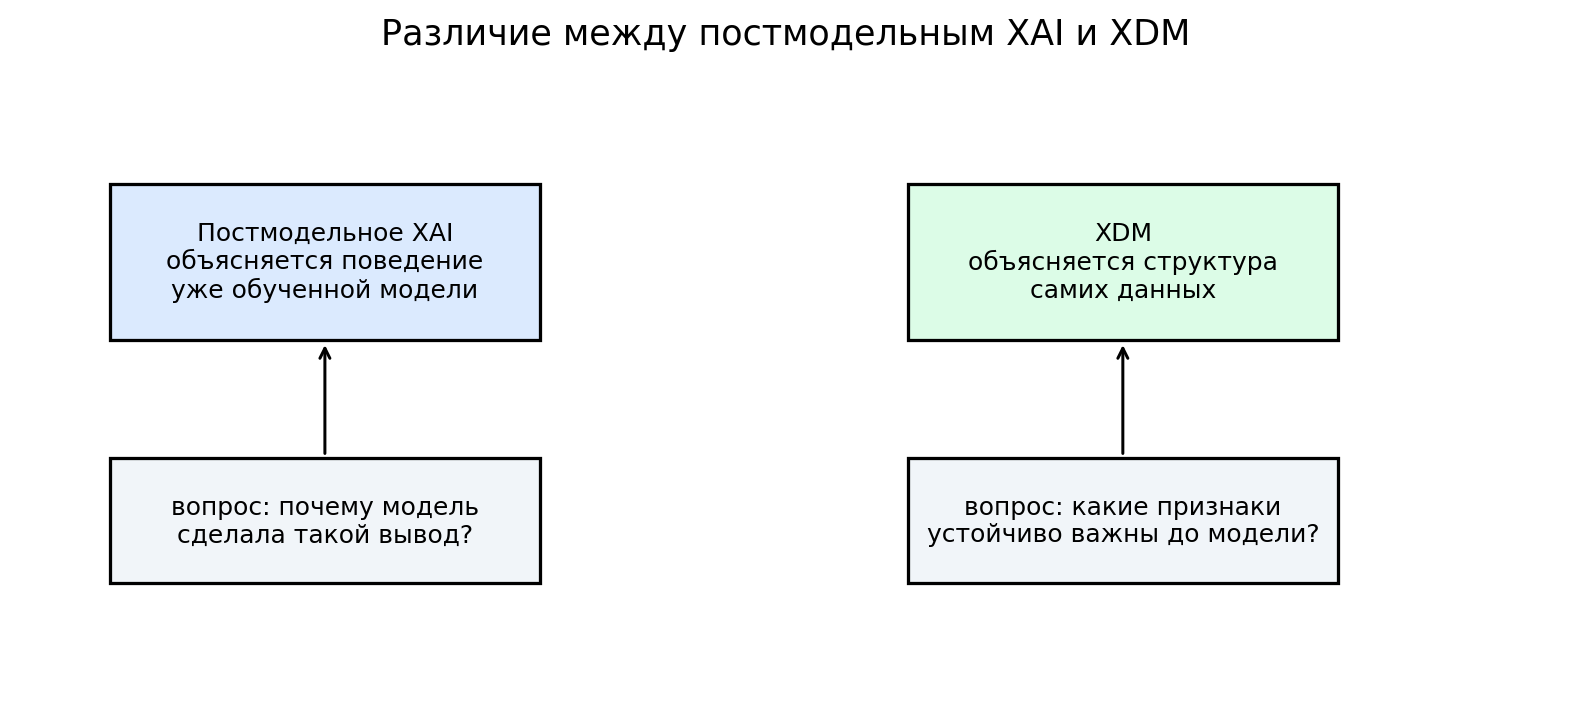</p>

<p align="center"><b>Рисунок 1. XAI объясняет модель, XDM объясняет данные</b></p>

## 1. Постмодельные объяснения и граница их применения

LIME объясняет поведение уже обученной модели через локальную суррогатную аппроксимацию. SHAP объясняет вклад признаков через аддитивные значения Шепли. Оба подхода полезны, когда модель уже существует. В XDM задача другая: нужно понять структуру данных до модели. Поэтому методы ниже не строят предсказательную функцию.

## 2. Каталог безмодельных методов

К безмодельным методам относятся фильтры отбора признаков, информационные меры, локальные контрастные методы, геометрические оценки, условные связи, анализ избыточности, правила подгрупп и проверка устойчивости рангов.

<p align="center">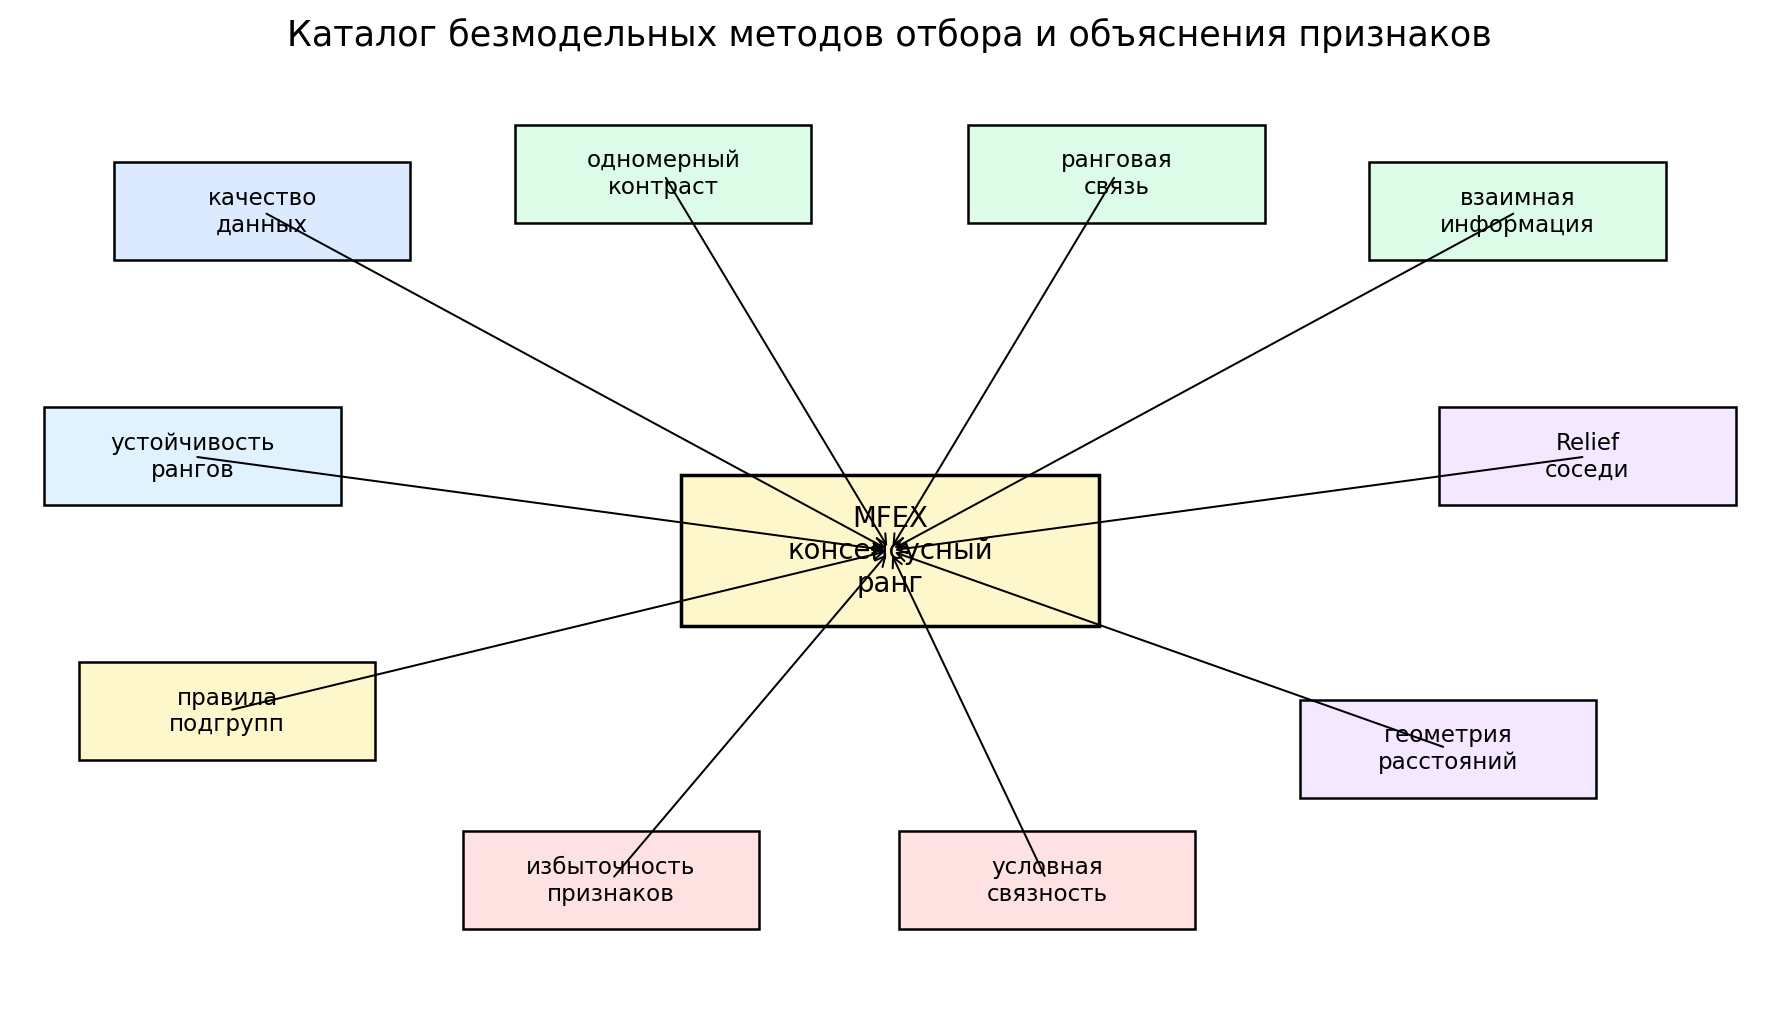</p>

<p align="center"><b>Рисунок 2. Каталог методов XDM</b></p>

## Аудит качества данных

Проверяются размер таблицы, типы признаков, пропуски, баланс целевой переменной и очевидные дубликаты. Этот блок не даёт ранга признака, но определяет, можно ли доверять дальнейшим оценкам.

## Одномерное различие классов

Метод сравнивает средние значения признака в классах 0 и 1. Если различие велико относительно разброса, признак получает высокий балл. Ограничение: метод видит только одномерный эффект.

## Ранговая связь

Используется абсолютная ранговая корреляция Спирмена между признаком и целью. Метод полезен для монотонных зависимостей и менее чувствителен к шкале, чем обычная линейная корреляция.

## Взаимная информация

Метод измеряет, насколько знание признака уменьшает неопределенность относительно цели. Он способен фиксировать нелинейные зависимости, но зависит от дискретизации и размера выборки.

## Relief-подход

Метод сравнивает ближайших соседей одного и разных классов. Признак важен, если он хорошо различает близкие объекты разных классов и не разрывает близкие объекты одного класса.

## Избыточность признаков

Высокий индивидуальный ранг не означает уникальную информацию. Избыточность показывает, дублирует ли признак другие сильные признаки.

## Геометрическая важность

Метод смотрит, ухудшается ли расстояниевая разделимость классов после удаления признака. Он не строит классификатор и не оценивает точность.

## Условная связность

Метод проверяет связь признака с целью после учета остальных признаков через частную корреляцию. Это не причинность, а остаточная линейная связь.

## Правила подгрупп

Метод ищет интервальные правила, в которых доля целевого класса отличается от базовой доли. Он переводит числовой результат в понятный предметный язык.

## Устойчивость рангов

Метод пересчитывает ранги на пересэмплированных строках. Признак считается устойчивым, если часто попадает в первые позиции.

## 3. Основные формулы

Взаимная информация, Relief, геометрическая сохранность структуры, частная корреляция, качество правила, консенсусный ранг и MFF-NoFit представлены ниже.

<p align="center">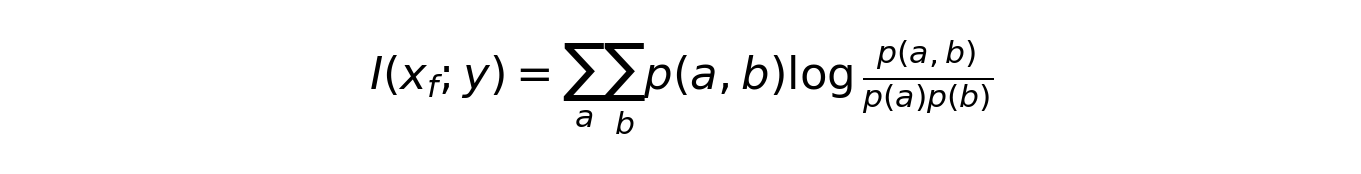</p>

<p align="center"><b>Взаимная информация</b></p>

<p align="center">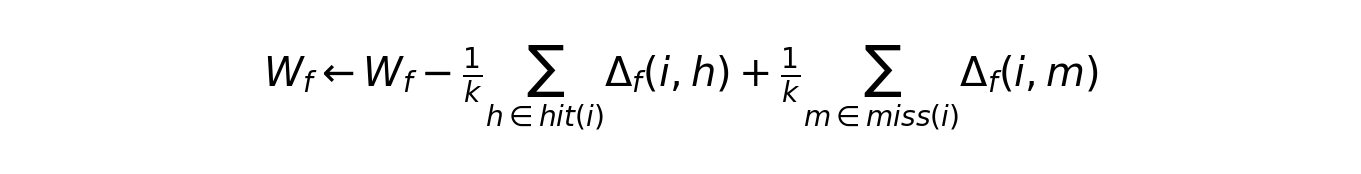</p>

<p align="center"><b>Relief-подход</b></p>

<p align="center">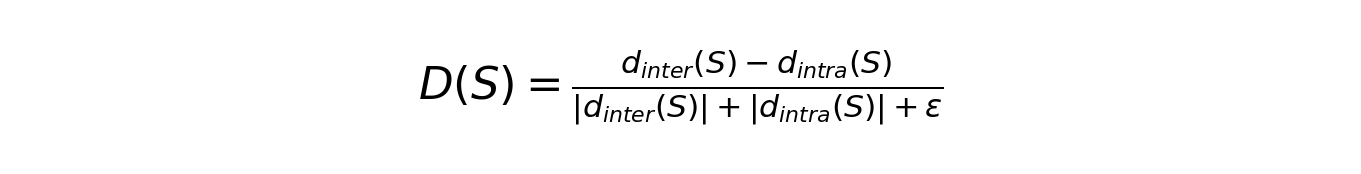</p>

<p align="center"><b>Сохранность целевой структуры</b></p>

<p align="center">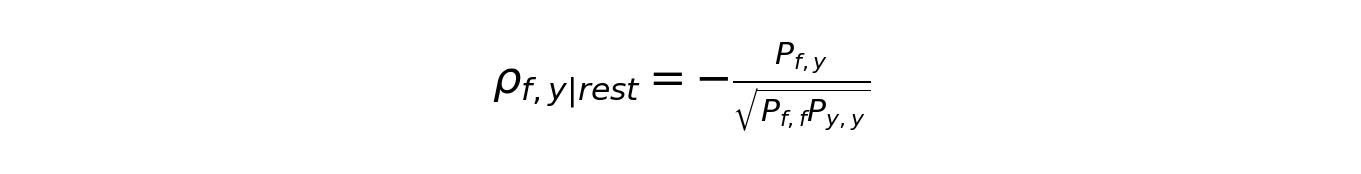</p>

<p align="center"><b>Частная корреляция</b></p>

<p align="center">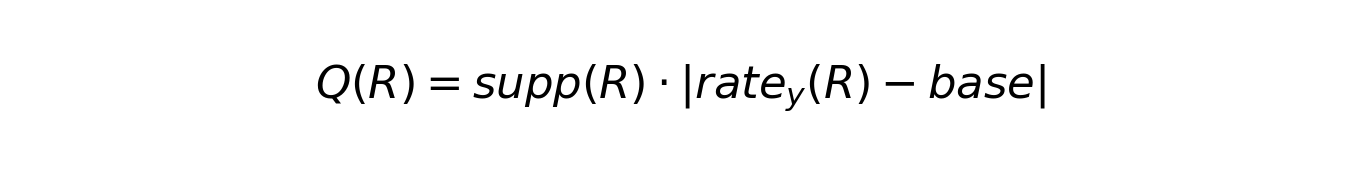</p>

<p align="center"><b>Качество правила</b></p>

<p align="center">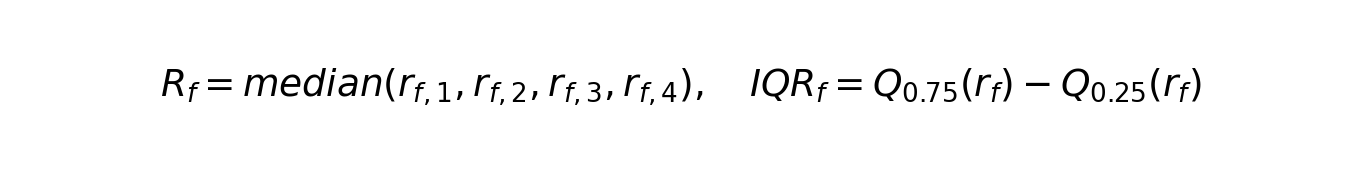</p>

<p align="center"><b>Консенсусный ранг и IQR</b></p>

<p align="center">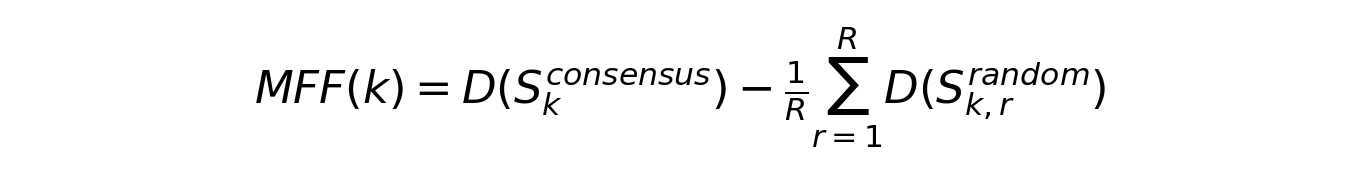</p>

<p align="center"><b>MFF-NoFit</b></p>

## 4. Почему ядро MFEX состоит из четырёх источников

Статистический источник объединяет информационный вклад и локальную различающую способность. Геометрический источник измеряет разделимость классов в пространстве признаков. Условный источник проверяет связь на фоне остальных признаков. Структурный источник даёт интерпретируемые правила. Эти четыре проекции не совпадают, поэтому их объединение через ранговый консенсус устойчивее, чем доверие одному методу.